<a href="https://colab.research.google.com/github/VakhromeevaKate/python-practice-algos/blob/master/636-01/hw-3-vakhromeeva-e-a-636-00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Метрики качества в машинном обучении

Метрики - числовые показатели, которые оценивают качество моделей машинного обучения. Правильный выбор метрики критически важен для:

- Сравнения моделей
- Настройки гиперпараметров
- Оценки бизнес-ценности модели



## Метрики для задач регрессии

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Создаем синтетические данные
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # 100 примеров, 1 признак
y = 2.5 * X.squeeze() + np.random.randn(100) * 2 + 5  # линейная зависимость + шум

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания
y_pred = model.predict(X_test)

## Основные метрики регрессии

In [ ]:
def calculate_regression_metrics(y_true, y_pred, model_name=""):
    """Вычисление метрик для регрессии"""

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"=== Метрики для {model_name} ===" if model_name else "=== Метрики ===")
    print(f"MAE (Средняя абсолютная ошибка): {mae:.4f}")
    print(f"MSE (Средняя квадратичная ошибка): {mse:.4f}")
    print(f"RMSE (Среднеквадратичная ошибка): {rmse:.4f}")
    print(f"R² (Коэффициент детерминации): {r2:.4f}")
    print()

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

# Вычисляем метрики для нашей модели
metrics = calculate_regression_metrics(y_test, y_pred, "Линейной регрессии")

=== Метрики для Линейной регрессии ===
MAE (Средняя абсолютная ошибка): 1.1947
MSE (Средняя квадратичная ошибка): 2.5238
RMSE (Среднеквадратичная ошибка): 1.5886
R² (Коэффициент детерминации): 0.9624



### Как выбор метрики влияет на результат регрессии

=== Сравнение моделей с разными типами ошибок ===
Модель 1: Несколько больших ошибок
=== Метрики для Модели 1 (с выбросами) ===
MAE (Средняя абсолютная ошибка): 2.5000
MSE (Средняя квадратичная ошибка): 37.5000
RMSE (Среднеквадратичная ошибка): 6.1237
R² (Коэффициент детерминации): 0.4415

Модель 2: Много маленьких ошибок
=== Метрики для Модели 2 (равномерный шум) ===
MAE (Средняя абсолютная ошибка): 2.4981
MSE (Средняя квадратичная ошибка): 10.2085
RMSE (Среднеквадратичная ошибка): 3.1951
R² (Коэффициент детерминации): 0.8480



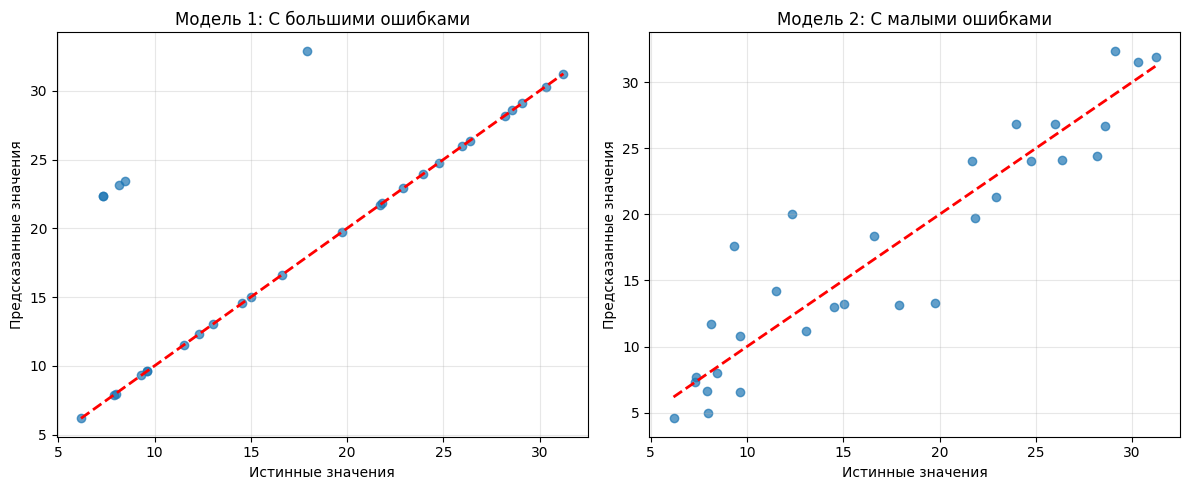

Сравнительная таблица метрик:
  Метрика  Модель 1 (большие ошибки)  Модель 2 (малые ошибки)
0     MAE                   2.500000                 2.498124
1     MSE                  37.500000                10.208493
2    RMSE                   6.123724                 3.195073
3      R²                   0.441531                 0.847970

Выводы:
1. MSE/RMSE сильнее штрафуют за большие ошибки (выбросы)
2. MAE более устойчива к выбросам
3. Выбор метрики зависит от бизнес-задачи!


In [ ]:
# Создадим две модели с разными характеристиками ошибок
np.random.seed(42)

# Симулируем предсказания двух разных моделей
# Модель 1: Несколько больших ошибок
y_pred_model1 = y_test.copy()
error_indices = np.random.choice(len(y_test), size=5, replace=False)
y_pred_model1[error_indices] += 15  # Добавляем большие ошибки

# Модель 2: Много маленьких ошибок
y_pred_model2 = y_test + np.random.randn(len(y_test)) * 3

print("=== Сравнение моделей с разными типами ошибок ===")
print("Модель 1: Несколько больших ошибок")
metrics1 = calculate_regression_metrics(y_test, y_pred_model1, "Модели 1 (с выбросами)")

print("Модель 2: Много маленьких ошибок")
metrics2 = calculate_regression_metrics(y_test, y_pred_model2, "Модели 2 (равномерный шум)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_model1, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Истинные значения')
axes[0].set_ylabel('Предсказанные значения')
axes[0].set_title('Модель 1: С большими ошибками')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred_model2, alpha=0.7)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Истинные значения')
axes[1].set_ylabel('Предсказанные значения')
axes[1].set_title('Модель 2: С малыми ошибками')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение метрик
comparison = pd.DataFrame({
    'Метрика': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Модель 1 (большие ошибки)': [metrics1['MAE'], metrics1['MSE'], metrics1['RMSE'], metrics1['R2']],
    'Модель 2 (малые ошибки)': [metrics2['MAE'], metrics2['MSE'], metrics2['RMSE'], metrics2['R2']]
})

print("Сравнительная таблица метрик:")
print(comparison)
print("\nВыводы:")
print("1. MSE/RMSE сильнее штрафуют за большие ошибки (выбросы)")
print("2. MAE более устойчива к выбросам")
print("3. Выбор метрики зависит от бизнес-задачи!")

## Метрики для задач классификации

In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns

# Создаем синтетические данные для бинарной классификации
X_clf, y_clf = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    weights=[0.9, 0.1],  # несбалансированные классы
    random_state=42
)

# Разделяем данные
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

# Обучаем модель
clf_model = LogisticRegression(random_state=42, max_iter=1000)
clf_model.fit(X_train_clf, y_train_clf)

# Предсказания
y_pred_clf = clf_model.predict(X_test_clf)
y_pred_proba = clf_model.predict_proba(X_test_clf)[:, 1]

### Основные метрики классификации

In [ ]:
def calculate_classification_metrics(y_true, y_pred, y_pred_proba=None, model_name=""):
    """Вычисление метрик для классификации"""

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"=== Метрики для {model_name} ===" if model_name else "=== Метрики ===")
    print(f"Accuracy (Точность): {accuracy:.4f}")
    print(f"Precision (Точность/Precision): {precision:.4f}")
    print(f"Recall (Полнота): {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")

    print("\nМатрица ошибок:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

# Вычисляем метрики
clf_metrics = calculate_classification_metrics(
    y_test_clf, y_pred_clf, y_pred_proba, "Логистической регрессии"
)

=== Метрики для Логистической регрессии ===
Accuracy (Точность): 0.9067
Precision (Точность/Precision): 0.6000
Recall (Полнота): 0.2903
F1-score: 0.3913
ROC-AUC: 0.8658

Матрица ошибок:
[[263   6]
 [ 22   9]]


Визуализация матрицы ошибок и ROC-кривой

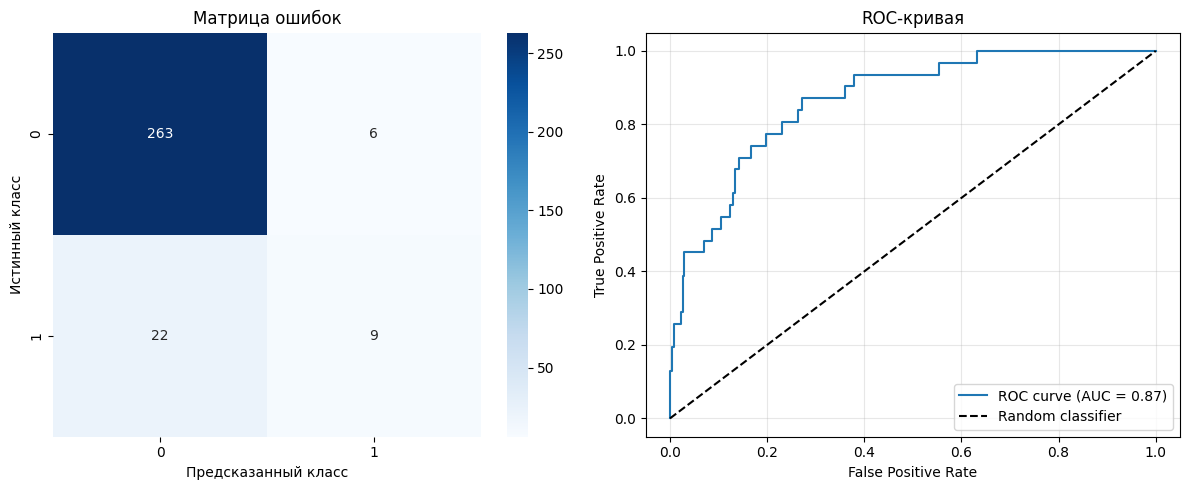

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Матрица ошибок
sns.heatmap(clf_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title('Матрица ошибок')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test_clf, y_pred_proba):.2f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Как выбор метрики влияет на результат классификации

In [ ]:
# Создадим два классификатора с разными характеристиками
np.random.seed(42)

# Классификатор 1: Консервативный (высокий precision, низкий recall)
# Имитируем консервативный классификатор - предсказывает 1 только при высокой уверенности
threshold_high = np.percentile(y_pred_proba, 90)  # 90-й перцентиль
y_pred_conservative = (y_pred_proba > threshold_high).astype(int)

# Классификатор 2: Агрессивный (низкий precision, высокий recall)
# Имитируем агрессивный классификатор - предсказывает 1 при малейшей уверенности
threshold_low = np.percentile(y_pred_proba, 10)  # 10-й перцентиль
y_pred_aggressive = (y_pred_proba > threshold_low).astype(int)

print("=== Сравнение разных стратегий классификации ===")
print("\nКлассификатор 1: Консервативный (высокий порог)")
metrics_cons = calculate_classification_metrics(y_test_clf, y_pred_conservative, model_name="Консервативного")

print("\nКлассификатор 2: Агрессивный (низкий порог)")
metrics_agg = calculate_classification_metrics(y_test_clf, y_pred_aggressive, model_name="Агрессивного")

print("\nОригинальный классификатор (порог 0.5):")
metrics_orig = calculate_classification_metrics(y_test_clf, y_pred_clf, model_name="Оригинального")

# Сравнительная таблица
comparison_clf = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1'],
    'Консервативный': [
        metrics_cons['accuracy'],
        metrics_cons['precision'],
        metrics_cons['recall'],
        metrics_cons['f1']
    ],
    'Агрессивный': [
        metrics_agg['accuracy'],
        metrics_agg['precision'],
        metrics_agg['recall'],
        metrics_agg['f1']
    ],
    'Оригинальный': [
        metrics_orig['accuracy'],
        metrics_orig['precision'],
        metrics_orig['recall'],
        metrics_orig['f1']
    ]
})

print("\nСравнительная таблица метрик классификации:")
print(comparison_clf)

print("\nВыводы:")
print("1. Консервативный классификатор:")
print("   - Высокий Precision: мало ложных срабатываний")
print("   - Низкий Recall: пропускает много положительных случаев")
print("   - Подходит когда False Positive дорого стоит (спам-фильтр, диагностика тяжелых болезней)")

print("\n2. Агрессивный классификатор:")
print("   - Низкий Precision: много ложных срабатываний")
print("   - Высокий Recall: находит почти все положительные случаи")
print("   - Подходит когда False Negative дорого стоит (поиск террористов, диагностика инфекций)")

print("\n3. Accuracy может вводить в заблуждение при несбалансированных классах!")

=== Сравнение разных стратегий классификации ===

Классификатор 1: Консервативный (высокий порог)
=== Метрики для Консервативного ===
Accuracy (Точность): 0.8900
Precision (Точность/Precision): 0.4667
Recall (Полнота): 0.4516
F1-score: 0.4590

Матрица ошибок:
[[253  16]
 [ 17  14]]

Классификатор 2: Агрессивный (низкий порог)
=== Метрики для Агрессивного ===
Accuracy (Точность): 0.2033
Precision (Точность/Precision): 0.1148
Recall (Полнота): 1.0000
F1-score: 0.2060

Матрица ошибок:
[[ 30 239]
 [  0  31]]

Оригинальный классификатор (порог 0.5):
=== Метрики для Оригинального ===
Accuracy (Точность): 0.9067
Precision (Точность/Precision): 0.6000
Recall (Полнота): 0.2903
F1-score: 0.3913

Матрица ошибок:
[[263   6]
 [ 22   9]]

Сравнительная таблица метрик классификации:
     Метрика  Консервативный  Агрессивный  Оригинальный
0   Accuracy        0.890000     0.203333      0.906667
1  Precision        0.466667     0.114815      0.600000
2     Recall        0.451613     1.000000      0.2903

## Итого:

### Для регрессии
- MAE: устойчива к выбросам, интерпретируема
- MSE/RMSE: штрафуют за большие ошибки
- R²: показывает долю объясненной дисперсии

### Для классификации
- Accuracy: хороша для сбалансированных данных
- Precision: важна, когда False Positive дорого стоит
- Recall: важна, когда False Negative дорого стоит
- F1: баланс между Precision и Recall
- ROC-AUC: оценивает качество ранжирования

### Основные принципы
- Метрика должна соответствовать бизнес-задаче
- Нельзя использовать accuracy при несбалансированных классах
- Всегда смотрите на несколько метрик
- Визуализация помогает понять поведение модели

### Рекомендации:
- Регрессия: начинайте с MAE и RMSE, смотрите на распределение ошибок
- Классификация: стройте confusion matrix, выбирайте метрику под задачу
- При настройке: используйте ту же метрику, что и для оценки

## Дополнительные метрики для рассмотрения:
- MAPE (Mean Absolute Percentage Error) - для регрессии
- Log Loss - для классификации с вероятностями
- Precision-Recall AUC - для несбалансированных данных
- Коэффициент корреляции - для регрессии"
- Средняя точность (Average Precision)